# Анализ Funding Rate для Binance

## Как работает Funding Rate на Binance?

Funding Rate — это периодический платеж между участниками рынка perpetual-контрактов.

Его задача удерживать цену perpetual-контракта близко к цене базового актива.

Если Funding Rate положительный, держатели long-позиций (покупатели) платят держателям short-позиций (продавцам).

Если Funding Rate отрицательный, держатели short-позиций платят держателям long-позиций.

По методике Binance Funding Rate зависит от двух основных компонентов:

- Interest Rate — процентная составляющая.
- Premium Index — показатель отклонения perpetual-контракта от индексной цены.

Premium Index рассчитывается по формуле:

\begin{equation}
P = \frac{\max(0, ImpactBidPrice - PriceIndex) - \max(0, PriceIndex - ImpactAskPrice)}{PriceIndex}
\end{equation}

где:

- `Impact Bid Price` — расчетная цена покупки с учетом заданного объема;
- `Impact Ask Price` — расчетная цена продажи с учетом заданного объема;
- `Price Index` — индексная цена базового актива.

Premium Index показывает, насколько perpetual-контракт отклоняется от индексной цены.

Binance рассчитывает Premium Index каждые 5 секунд. В течение funding-периода эти значения усредняются с учетом времени: более поздние наблюдения получают больший вес.

Средний Premium Index:

\begin{equation}
P_{avg} = \frac{1P_1 + 2P_2 + 3P_3 + \dots + nP_n}{1 + 2 + 3 + \dots + n}
\end{equation} 

После этого Funding Rate рассчитывается на основе Average Premium Index и Interest Rate.

Для стандартного 8-часового funding-интервала базовая формула имеет вид:

\begin{equation}
F = P_{avg} + Clamp(I - P_{avg}, -0.05\%, 0.05\%)
\end{equation}

где:

- `F` — Funding Rate;
- `P_avg` — средний Premium Index;
- `I` — Interest Rate;
- `Clamp` — функция, ограничивающая значение заданным диапазоном.

По умолчанию Interest Rate для большинства perpetual-контрактов Binance составляет 0.01% на 8-часовой funding-период.

Для стандартного 8-часового интервала funding проводится в 00:00, 08:00 и 16:00 UTC.

При этом Binance может изменять funding-интервал для отдельных perpetual-контрактов в зависимости от рыночных условий.

Так, Funding Rate зависит от того, насколько perpetual-контракт отклоняется от индексной цены в течение funding-периода.

Официальное описание методики Binance:

[Introduction to Binance Futures Funding Rates](https://www.binance.com/en-AE/support/faq/detail/360033525031)

## 1. Получение опубликованных Funding Rate Binance

Funding Rate не рассчитывается самостоятельно по формуле Binance. Вместо этого используются фактические исторические значения Funding Rate, опубликованные Binance для perpetual-контрактов BTCUSDT и ETHUSDT.

Данные загружаются через публичный Binance Futures API:

`/fapi/v1/fundingRate`

Для каждого инструмента получаем последние опубликованные значения Funding Rate и время их применения.

Далее:

- `fundingTime` переводится из Unix timestamp в формат даты и времени;
- `fundingRate` преобразуется в числовой формат для дальнейшего анализа;
- полученные значения будут сопоставлены с записанными данными spot и perpetual.

In [2]:
import requests
import pandas as pd

def get_funding_history(symbol, limit=20):
    url = "https://fapi.binance.com/fapi/v1/fundingRate"
    params = {
        "symbol": symbol,
        "limit": limit
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    df = pd.DataFrame(response.json())

    df["fundingTime"] = pd.to_datetime(
        df["fundingTime"],
        unit="ms",
        utc=True
    )

    df["fundingRate"] = pd.to_numeric(df["fundingRate"])

    return df


btc_funding = get_funding_history("BTCUSDT")
eth_funding = get_funding_history("ETHUSDT")

btc_funding.tail()

,symbol,fundingTime,fundingRate,markPrice,rateType
15,BTCUSDT,2026-09-02 00:00:00+00:00,0.000080,77403.12535507,Regular
16,BTCUSDT,2026-09-02 08:00:00.001000+00:00,0.000080,77444.80000000,Regular
17,BTCUSDT,2026-09-02 16:00:00.005000+00:00,0.000038,77250.98157246,Regular
18,BTCUSDT,2026-09-03 00:00:00+00:00,0.000073,77301.45594203,Regular
19,BTCUSDT,2026-09-03 08:00:00+00:00,0.000059,77622.37865217,Regular


In [3]:
btc_funding["fundingTime_MSK"] = btc_funding["fundingTime"].dt.tz_convert("Europe/Moscow")
eth_funding["fundingTime_MSK"] = eth_funding["fundingTime"].dt.tz_convert("Europe/Moscow")

btc_funding[["symbol", "fundingTime_MSK", "fundingRate"]].tail(10)

,symbol,fundingTime_MSK,fundingRate
10,BTCUSDT,2026-08-31 11:00:00.002000+03:00,0.000100
11,BTCUSDT,2026-08-31 19:00:00.001000+03:00,0.000100
12,BTCUSDT,2026-09-01 03:00:00.005000+03:00,0.000085
13,BTCUSDT,2026-09-01 11:00:00+03:00,0.000100
14,BTCUSDT,2026-09-01 19:00:00+03:00,0.000038
15,BTCUSDT,2026-09-02 03:00:00+03:00,0.000080
16,BTCUSDT,2026-09-02 11:00:00.001000+03:00,0.000080
17,BTCUSDT,2026-09-02 19:00:00.005000+03:00,0.000038
18,BTCUSDT,2026-09-03 03:00:00+03:00,0.000073
19,BTCUSDT,2026-09-03 11:00:00+03:00,0.000059


In [4]:
eth_funding[["symbol", "fundingTime_MSK", "fundingRate"]].tail(10)


,symbol,fundingTime_MSK,fundingRate
10,ETHUSDT,2026-08-31 11:00:00.002000+03:00,3.522000e-05
11,ETHUSDT,2026-08-31 19:00:00.001000+03:00,7.702000e-05
12,ETHUSDT,2026-09-01 03:00:00.005000+03:00,5.716000e-05
13,ETHUSDT,2026-09-01 11:00:00+03:00,8.569000e-05
14,ETHUSDT,2026-09-01 19:00:00+03:00,1.100000e-05
15,ETHUSDT,2026-09-02 03:00:00+03:00,9.200000e-07
16,ETHUSDT,2026-09-02 11:00:00.001000+03:00,5.096000e-05
17,ETHUSDT,2026-09-02 19:00:00.005000+03:00,5.184000e-05
18,ETHUSDT,2026-09-03 03:00:00+03:00,8.972000e-05
19,ETHUSDT,2026-09-03 11:00:00+03:00,8.397000e-05


## BTCUSDT: Spot и Perpetual за весь период сбора данных

На графике сравниваются цена BTCUSDT Spot и цена BTCUSDT Perpetual за весь доступный период сбора данных.

Для уменьшения количества точек данные агрегируются до одной минуты. Для каждой минуты используется последнее доступное значение mid-price:

\begin{equation}
MidPrice = \frac{BidPrice + AskPrice}{2}
\end{equation}

На графике также отмечены моменты выплаты Funding в 03:00 и 11:00 МСК.

In [16]:
import pandas as pd
import plotly.graph_objects as go

spot_file = "btcusdt_spot_2026-09-03_00-23-03_raw.csv"
perp_file = "btcusdt_usdm_futures_2026-09-03_00-23-30_raw.csv"


def load_full_1min(file):
    parts = []

    for chunk in pd.read_csv(file, chunksize=500_000):

        chunk["time"] = (
            pd.to_datetime(
                chunk["receive_time_ms"],
                unit="ms",
                utc=True
            )
            .dt.tz_convert("Europe/Moscow")
        )

        chunk["mid_price"] = (
            chunk["bid_price"] + chunk["ask_price"]
        ) / 2

        part = (
            chunk
            .set_index("time")["mid_price"]
            .resample("1min")
            .last()
            .dropna()
        )

        parts.append(part)

    result = pd.concat(parts)

    # Одна и та же минута может попасть в соседние chunks
    result = result.groupby(level=0).last()

    return result


btc_spot_full = load_full_1min(spot_file)
btc_perp_full = load_full_1min(perp_file)

print("Spot:", btc_spot_full.index.min(), "—", btc_spot_full.index.max())
print("Perpetual:", btc_perp_full.index.min(), "—", btc_perp_full.index.max())

Spot: 2026-09-03 00:23:00+03:00 — 2026-09-03 15:59:00+03:00
Perpetual: 2026-09-03 00:23:00+03:00 — 2026-09-03 15:59:00+03:00


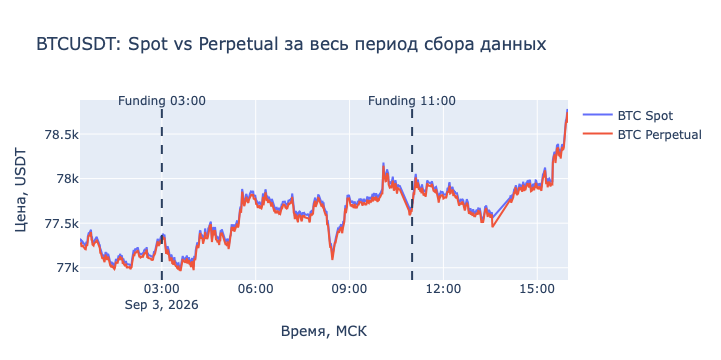

In [17]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=btc_spot_full.index,
        y=btc_spot_full.values,
        mode="lines",
        name="BTC Spot"
    )
)

fig.add_trace(
    go.Scatter(
        x=btc_perp_full.index,
        y=btc_perp_full.values,
        mode="lines",
        name="BTC Perpetual"
    )
)

funding_times = [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]

for funding_time, label in funding_times:
    fig.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig.update_layout(
    title="BTCUSDT: Spot vs Perpetual за весь период сбора данных",
    xaxis_title="Время, МСК",
    yaxis_title="Цена, USDT",
    hovermode="x unified"
)

fig.show()

In [18]:
fig.write_html("btc_spot_vs_perp_full_funding.html")

## BTCUSDT: динамика spread за весь период

Spread рассчитывается как разница между ценой BTCUSDT Perpetual и BTCUSDT Spot:

\begin{equation}
Spread = PerpetualPrice - SpotPrice
\end{equation}

Отрицательный spread означает, что цена perpetual-контракта ниже цены Spot. Чем ближе spread к нулю, тем ближе цены двух рынков друг к другу.

На графике отмечены моменты выплаты Funding в 03:00 и 11:00 МСК.

In [21]:
check_1330 = btc_spread_full.loc[
    "2026-09-03 13:25:00+03:00":
    "2026-09-03 13:35:00+03:00"
].copy()

check_1330[
    ["spot_mid", "perp_mid", "spread_usd"]
]

,spot_mid,perp_mid,spread_usd
time,,,
2026-09-03 13:25:00+03:00,77613.085,77570.05,-43.035
2026-09-03 13:26:00+03:00,77649.995,77617.15,-32.845
2026-09-03 13:27:00+03:00,77636.175,77600.05,-36.125
2026-09-03 13:28:00+03:00,77639.965,77607.95,-32.015
2026-09-03 13:29:00+03:00,77630.965,77594.25,-36.715
2026-09-03 13:30:00+03:00,77594.405,77562.05,-32.355
2026-09-03 13:31:00+03:00,77600.625,77572.65,-27.975
2026-09-03 13:32:00+03:00,77610.005,77586.85,-23.155
2026-09-03 13:33:00+03:00,77622.425,77596.45,-25.975


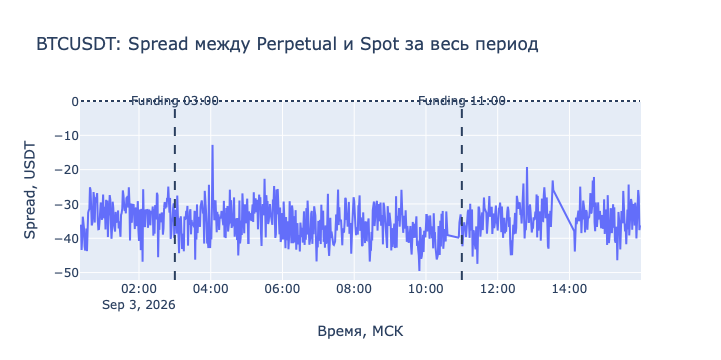

In [23]:
import pandas as pd
import plotly.graph_objects as go

# --------------------------------------------------
# 1. Объединяем минутные Spot и Perpetual
# --------------------------------------------------

btc_spread_full = pd.concat(
    [
        btc_spot_full.rename("spot_mid"),
        btc_perp_full.rename("perp_mid")
    ],
    axis=1
).dropna()

# Spread = Perpetual - Spot
btc_spread_full["spread_usd"] = (
    btc_spread_full["perp_mid"]
    - btc_spread_full["spot_mid"]
)


# --------------------------------------------------
# 2. Убираем последнюю минуту
# Она могла быть записана не полностью
# --------------------------------------------------

btc_spread_clean = btc_spread_full.iloc[:-1].copy()


# --------------------------------------------------
# 3. Период без интернета
# --------------------------------------------------

gap_start = pd.Timestamp(
    "2026-09-03 13:34:00",
    tz="Europe/Moscow"
)

gap_end = pd.Timestamp(
    "2026-09-03 13:50:00",
    tz="Europe/Moscow"
)

# Удаляем ненадёжные точки внутри разрыва.
# Plotly соединит последнюю точку до gap
# с первой точкой после gap прямой линией.

gap_mask = (
    (btc_spread_clean.index >= gap_start) &
    (btc_spread_clean.index <= gap_end)
)

btc_spread_clean.loc[
    gap_mask,
    "spread_usd"
] = float("nan")


# --------------------------------------------------
# 4. График
# --------------------------------------------------

fig_spread = go.Figure()

fig_spread.add_trace(
    go.Scatter(
        x=btc_spread_clean.index,
        y=btc_spread_clean["spread_usd"],
        mode="lines",
        name="Spread: Perpetual - Spot",

        # Соединяем участок без данных прямой
        connectgaps=True
    )
)


# --------------------------------------------------
# 5. Нулевая линия
# --------------------------------------------------

fig_spread.add_shape(
    type="line",
    x0=btc_spread_clean.index.min(),
    x1=btc_spread_clean.index.max(),
    y0=0,
    y1=0,
    xref="x",
    yref="y",
    line=dict(dash="dot")
)


# --------------------------------------------------
# 6. Funding
# --------------------------------------------------

funding_times = [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]

for funding_time, label in funding_times:

    fig_spread.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_spread.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )


# --------------------------------------------------
# 7. Оформление
# --------------------------------------------------

fig_spread.update_layout(
    title="BTCUSDT: Spread между Perpetual и Spot за весь период",
    xaxis_title="Время, МСК",
    yaxis_title="Spread, USDT",
    hovermode="x unified"
)

fig_spread.show()

In [24]:
fig_spread.write_html(
    "btc_spread_full_funding.html",
    include_plotlyjs=True
)

print("График сохранён: btc_spread_full_funding.html")

График сохранён: btc_spread_full_funding.html


## BTCUSDT: средний spread по 30-минутным интервалам

Для анализа более устойчивой динамики минутные значения spread дополнительно агрегируются по 30-минутным интервалам.

Для каждого интервала рассчитывается среднее значение spread.

In [25]:
# Средний spread за каждые 30 минут

btc_spread_30min = (
    btc_spread_clean["spread_usd"]
    .resample("30min")
    .mean()
    .dropna()
)

btc_spread_30min

time
2026-09-03 00:00:00+03:00   -38.256429
2026-09-03 00:30:00+03:00   -33.056667
2026-09-03 01:00:00+03:00   -34.052667
2026-09-03 01:30:00+03:00   -31.687667
2026-09-03 02:00:00+03:00   -34.311667
2026-09-03 02:30:00+03:00   -33.097667
2026-09-03 03:00:00+03:00   -35.658000
2026-09-03 03:30:00+03:00   -34.848000
2026-09-03 04:00:00+03:00   -33.453667
2026-09-03 04:30:00+03:00   -35.147333
2026-09-03 05:00:00+03:00   -32.550000
2026-09-03 05:30:00+03:00   -32.747667
2026-09-03 06:00:00+03:00   -37.640333
2026-09-03 06:30:00+03:00   -37.379000
2026-09-03 07:00:00+03:00   -38.303333
2026-09-03 07:30:00+03:00   -34.599667
2026-09-03 08:00:00+03:00   -37.151667
2026-09-03 08:30:00+03:00   -33.884667
2026-09-03 09:00:00+03:00   -36.143000
2026-09-03 09:30:00+03:00   -40.349000
2026-09-03 10:00:00+03:00   -38.586333
2026-09-03 10:30:00+03:00   -37.310385
2026-09-03 11:00:00+03:00   -37.450000
2026-09-03 11:30:00+03:00   -33.557963
2026-09-03 12:00:00+03:00   -35.893000
2026-09-03 12:30:00+

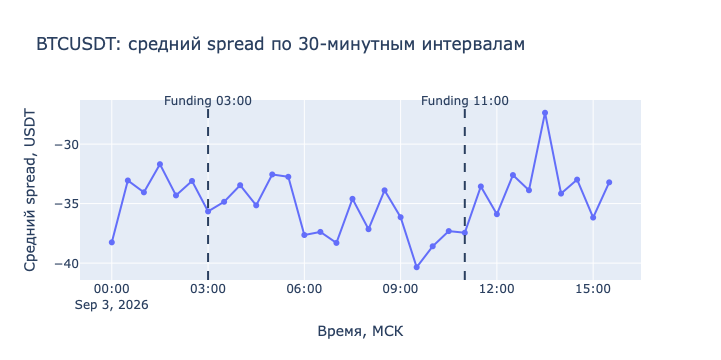

In [26]:
fig_30min = go.Figure()

fig_30min.add_trace(
    go.Scatter(
        x=btc_spread_30min.index,
        y=btc_spread_30min.values,
        mode="lines+markers",
        name="Средний spread за 30 минут"
    )
)

for funding_time, label in [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]:
    fig_30min.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_30min.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig_30min.update_layout(
    title="BTCUSDT: средний spread по 30-минутным интервалам",
    xaxis_title="Время, МСК",
    yaxis_title="Средний spread, USDT",
    hovermode="x unified"
)

fig_30min.show()

### Наблюдение

После Funding в 03:00 МСК немедленного сокращения spread не наблюдается: в следующем 30-минутном интервале spread становится более отрицательным, после чего постепенно возвращается к предыдущему диапазону.

После Funding в 11:00 МСК резкого изменения также нет, однако в последующих интервалах spread сокращается по модулю.

Таким образом, на 30-минутном масштабе возможная реакция spread проявляется не сразу и отличается для разных Funding-событий. Явного одинакового эффекта после Funding на обоих наблюдениях не видно.



## BTCUSDT: средний spread по часовым интервалам

Для оценки общего тренда spread дополнительно рассчитывается среднее значение за каждый час.

Часовая агрегация сильнее сглаживает краткосрочные колебания и позволяет проверить, сохраняются ли изменения, наблюдаемые на минутных и 30-минутных данных.

In [27]:
btc_spread_1h = (
    btc_spread_clean["spread_usd"]
    .resample("1h")
    .mean()
    .dropna()
)

btc_spread_1h

time
2026-09-03 00:00:00+03:00   -34.040405
2026-09-03 01:00:00+03:00   -32.870167
2026-09-03 02:00:00+03:00   -33.704667
2026-09-03 03:00:00+03:00   -35.253000
2026-09-03 04:00:00+03:00   -34.300500
2026-09-03 05:00:00+03:00   -32.648833
2026-09-03 06:00:00+03:00   -37.509667
2026-09-03 07:00:00+03:00   -36.451500
2026-09-03 08:00:00+03:00   -35.518167
2026-09-03 09:00:00+03:00   -38.246000
2026-09-03 10:00:00+03:00   -38.200581
2026-09-03 11:00:00+03:00   -35.606404
2026-09-03 12:00:00+03:00   -34.247667
2026-09-03 13:00:00+03:00   -33.112353
2026-09-03 14:00:00+03:00   -33.479423
2026-09-03 15:00:00+03:00   -34.718390
Freq: h, Name: spread_usd, dtype: float64

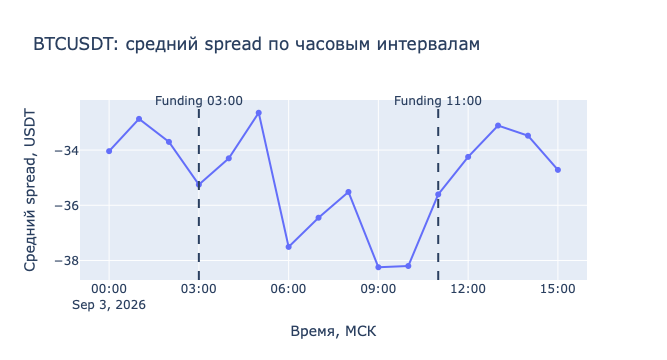

In [28]:
fig_1h = go.Figure()

fig_1h.add_trace(
    go.Scatter(
        x=btc_spread_1h.index,
        y=btc_spread_1h.values,
        mode="lines+markers",
        name="Средний spread за 1 час"
    )
)

for funding_time, label in [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]:
    fig_1h.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_1h.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig_1h.update_layout(
    title="BTCUSDT: средний spread по часовым интервалам",
    xaxis_title="Время, МСК",
    yaxis_title="Средний spread, USDT",
    hovermode="x unified"
)

fig_1h.show()

### Наблюдение

На часовом масштабе краткосрочные колебания spread значительно сглаживаются, и становится лучше виден общий внутридневной тренд.

После Funding в 03:00 МСК средний spread в течение следующих часов сначала сокращается по модулю, однако затем наблюдается более существенное увеличение расхождения между Spot и Perpetual.

После Funding в 11:00 МСК, напротив, в последующие часы наблюдается постепенное сокращение spread по модулю.

При этом часовая агрегация скрывает краткосрочную реакцию непосредственно после Funding. Поэтому для анализа поведения spread около момента выплаты более информативными являются 30-минутные и минутные данные, а часовые значения используются для оценки общего тренда.

# Анализ завершающего Funding в 19:00 

В данном разделе отдельно рассматривается третее Funding-событие за исследуемый период с 16:00 до 22:00.

Сначала сравнивается динамика цен Spot и Perpetual в районе Funding, после чего отдельно анализируется spread между ними:

**Spread = Perpetual mid-price − Spot mid-price**

Отрицательный spread означает, что цена Perpetual находится ниже цены Spot, положительный — выше.

In [4]:
import pandas as pd

def load_full_1min(file):
    parts = []

    for chunk in pd.read_csv(file, chunksize=500_000):
        chunk["time"] = (
            pd.to_datetime(chunk["receive_time_ms"], unit="ms", utc=True)
            .dt.tz_convert("Europe/Moscow")
        )

        chunk["mid_price"] = (
            chunk["bid_price"] + chunk["ask_price"]
        ) / 2

        part = (
            chunk
            .set_index("time")["mid_price"]
            .resample("1min")
            .last()
            .dropna()
        )

        parts.append(part)

    result = pd.concat(parts)
    result = result.groupby(level=0).last()

    return result


btc_spot_full = load_full_1min(
    "btcusdt_spot_2026-09-03_00-23-03_raw.csv"
)

btc_perp_full = load_full_1min(
    "btcusdt_usdm_futures_2026-09-03_00-23-30_raw.csv"
)

print("BTC Spot:", btc_spot_full.index.min(), "→", btc_spot_full.index.max())
print("BTC Perp:", btc_perp_full.index.min(), "→", btc_perp_full.index.max())

BTC Spot: 2026-09-03 00:23:00+03:00 → 2026-09-03 22:02:00+03:00
BTC Perp: 2026-09-03 00:23:00+03:00 → 2026-09-03 22:02:00+03:00


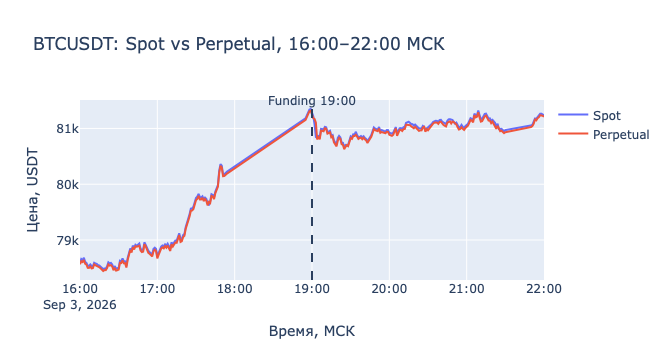

In [3]:
import plotly.graph_objects as go
import pandas as pd

start = pd.Timestamp("2026-09-03 16:00:00", tz="Europe/Moscow")
end = pd.Timestamp("2026-09-03 22:00:00", tz="Europe/Moscow")
funding_time = pd.Timestamp("2026-09-03 19:00:00", tz="Europe/Moscow")

btc_spot_19 = btc_spot_full.loc[start:end]
btc_perp_19 = btc_perp_full.loc[start:end]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=btc_spot_19.index,
    y=btc_spot_19.values,
    mode="lines",
    name="Spot"
))

fig.add_trace(go.Scatter(
    x=btc_perp_19.index,
    y=btc_perp_19.values,
    mode="lines",
    name="Perpetual"
))

fig.add_shape(
    type="line",
    x0="2026-09-03 19:00:00",
    x1="2026-09-03 19:00:00",
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(dash="dash")
)

fig.add_annotation(
    x="2026-09-03 19:00:00",
    y=1,
    xref="x",
    yref="paper",
    text="Funding 19:00",
    showarrow=False,
    yshift=10
)

fig.update_layout(
    title="BTCUSDT: Spot vs Perpetual, 16:00–22:00 МСК",
    xaxis_title="Время, МСК",
    yaxis_title="Цена, USDT",
    hovermode="x unified"
)

fig.show()

In [5]:
fig.write_html("btc_spot_vs_perp_funding_19.html")

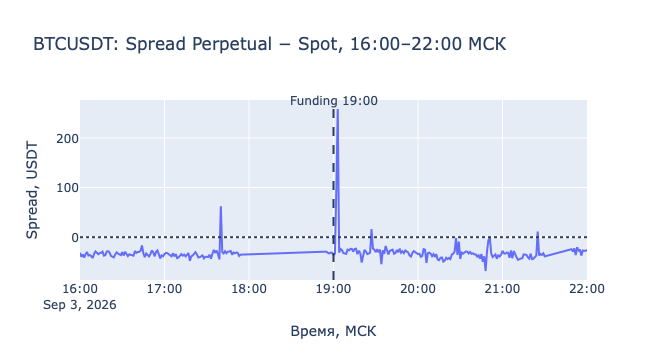

In [6]:
btc_spread_19 = pd.concat(
    [
        btc_spot_full.rename("spot_mid"),
        btc_perp_full.rename("perp_mid")
    ],
    axis=1
).dropna()

btc_spread_19["spread_usd"] = (
    btc_spread_19["perp_mid"] - btc_spread_19["spot_mid"]
)

btc_spread_19 = btc_spread_19.loc[start:end]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=btc_spread_19.index,
    y=btc_spread_19["spread_usd"],
    mode="lines",
    name="Spread"
))

fig.add_shape(
    type="line",
    x0="2026-09-03 19:00:00",
    x1="2026-09-03 19:00:00",
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(dash="dash")
)

fig.add_annotation(
    x="2026-09-03 19:00:00",
    y=1,
    xref="x",
    yref="paper",
    text="Funding 19:00",
    showarrow=False,
    yshift=10
)

fig.add_hline(
    y=0,
    line_dash="dot"
)

fig.update_layout(
    title="BTCUSDT: Spread Perpetual − Spot, 16:00–22:00 МСК",
    xaxis_title="Время, МСК",
    yaxis_title="Spread, USDT",
    hovermode="x unified"
)

fig.show()

fig.write_html("btc_spread_16_22_funding_19.html")

### Наблюдение

30-минутная агрегация позволяет лучше увидеть изменение spread вокруг Funding в 19:00 МСК, исключив большую часть краткосрочного минутного шума.

Отрицательные значения spread означают, что цена Perpetual находится ниже цены Spot. Движение spread в сторону нуля соответствует сближению цен, а увеличение отрицательного значения по модулю — расширению расхождения.

Для оценки реакции на Funding необходимо сравнить среднее значение spread непосредственно перед 19:00 и в первых 30-минутных интервалах после выплаты.

**Примечание:** в рассматриваемом периоде присутствует разрыв в исходных данных из-за временного прекращения интернет-соединения. На графике соседние наблюдения визуально соединены линией, однако отсутствующий интервал не используется в количественных расчётах.

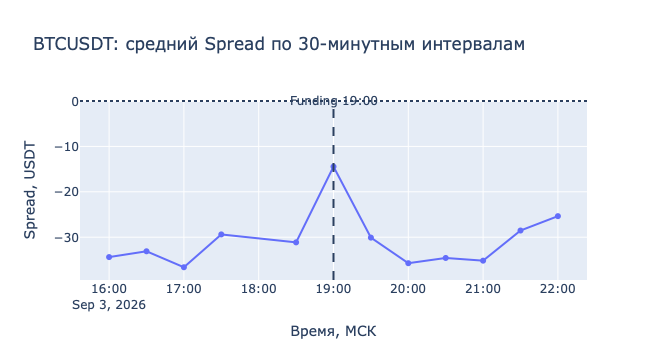

In [9]:
btc_spread_30 = (
    btc_spread_19["spread_usd"]
    .resample("30min")
    .mean()
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=btc_spread_30.index,
    y=btc_spread_30.values,
    mode="lines+markers",
    name="30-min average spread",
    connectgaps=True
))
fig.add_shape(
    type="line",
    x0="2026-09-03 19:00:00",
    x1="2026-09-03 19:00:00",
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(dash="dash")
)

fig.add_annotation(
    x="2026-09-03 19:00:00",
    y=1,
    xref="x",
    yref="paper",
    text="Funding 19:00",
    showarrow=False,
    yshift=10
)

fig.add_hline(
    y=0,
    line_dash="dot"
)

fig.update_layout(
    title="BTCUSDT: средний Spread по 30-минутным интервалам",
    xaxis_title="Время, МСК",
    yaxis_title="Spread, USDT",
    hovermode="x unified"
)

fig.show()

fig.write_html("btc_spread_30min_funding_19.html")

### Вывод

Перед Funding в 19:00 МСК spread BTCUSDT заметно сокращается по модулю: к моменту Funding он приближается примерно к -15 USDT, то есть цены Perpetual и Spot существенно сближаются.

Сразу после Funding spread снова увеличивается по модулю и возвращается примерно к -30 USDT, а затем в течение следующих интервалов остается в диапазоне около -30-(-36) USDT.

Таким образом, в данном случае наиболее выраженное сближение Spot и Perpetual наблюдается не после выплаты Funding, а непосредственно перед ней. После Funding мгновенного дальнейшего сближения не происходит — наоборот, расхождение снова увеличивается.

## ETHUSDT: Spot и Perpetual за весь период сбора данных

На графике сравниваются цена ETHUSDT Spot и цена ETHUSDT Perpetual за весь период сбора данных.

Данные агрегируются до одной минуты. Для каждой минуты используется последнее доступное значение mid-price:

\begin{equation}
MidPrice = \frac{BidPrice + AskPrice}{2}
\end{equation}

На графике отмечены моменты выплаты Funding в 03:00 и 11:00 МСК.

In [29]:
eth_spot_file = "ethusdt_spot_2026-09-03_00-23-49_raw.csv"
eth_perp_file = "ethusdt_usdm_futures_2026-09-03_00-24-09_raw.csv"

eth_spot_full = load_full_1min(eth_spot_file)
eth_perp_full = load_full_1min(eth_perp_file)

print("Spot:", eth_spot_full.index.min(), "—", eth_spot_full.index.max())
print("Perpetual:", eth_perp_full.index.min(), "—", eth_perp_full.index.max())

Spot: 2026-09-03 00:23:00+03:00 — 2026-09-03 16:43:00+03:00
Perpetual: 2026-09-03 00:24:00+03:00 — 2026-09-03 16:43:00+03:00


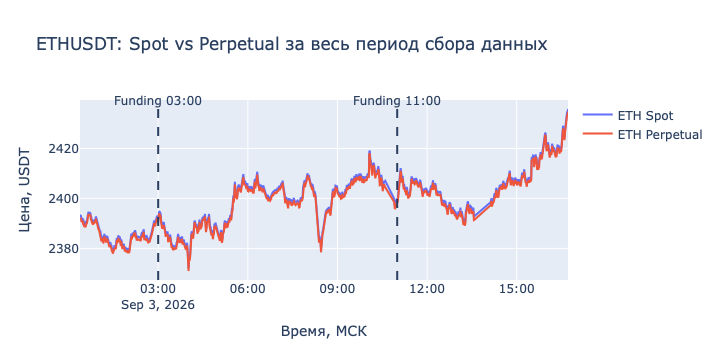

In [30]:
fig_eth = go.Figure()

fig_eth.add_trace(
    go.Scatter(
        x=eth_spot_full.index,
        y=eth_spot_full.values,
        mode="lines",
        name="ETH Spot"
    )
)

fig_eth.add_trace(
    go.Scatter(
        x=eth_perp_full.index,
        y=eth_perp_full.values,
        mode="lines",
        name="ETH Perpetual"
    )
)

funding_times = [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]

for funding_time, label in funding_times:
    fig_eth.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_eth.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig_eth.update_layout(
    title="ETHUSDT: Spot vs Perpetual за весь период сбора данных",
    xaxis_title="Время, МСК",
    yaxis_title="Цена, USDT",
    hovermode="x unified"
)

fig_eth.show()

In [31]:
fig_eth.write_html(
    "eth_spot_vs_perp_full_funding.html",
    include_plotlyjs=True
)

## ETHUSDT: динамика spread за весь период

Spread рассчитывается как разница между ценой ETHUSDT Perpetual и ETHUSDT Spot:

\begin{equation}
Spread = PerpetualPrice - SpotPrice
\end{equation}

Отрицательный spread означает, что цена perpetual-контракта находится ниже цены Spot.

На графике отмечены моменты Funding в 03:00 и 11:00 МСК.

/var/folders/x4/ng1slsx161z8z3235nhw7rtr0000gn/T/ipykernel_35570/3791545775.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  eth_spread_full = pd.concat(


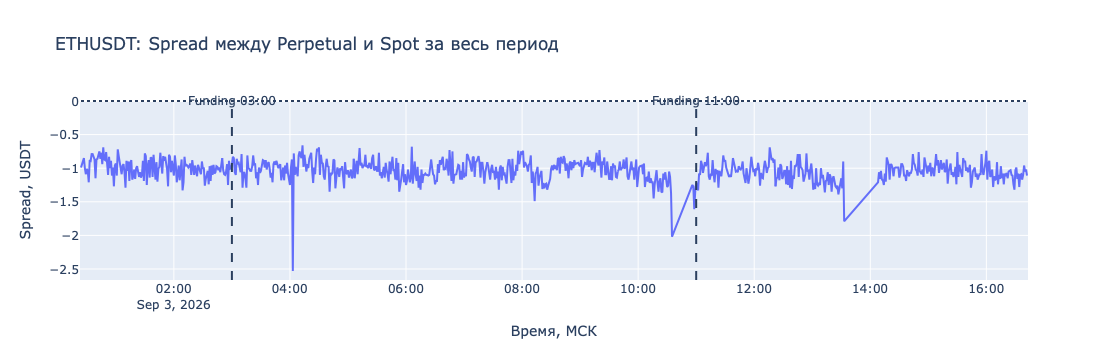

In [32]:
# Объединяем минутные данные Spot и Perpetual

eth_spread_full = pd.concat(
    [
        eth_spot_full.rename("spot_mid"),
        eth_perp_full.rename("perp_mid")
    ],
    axis=1
).dropna()

# Считаем spread

eth_spread_full["spread_usd"] = (
    eth_spread_full["perp_mid"]
    - eth_spread_full["spot_mid"]
)

# Копия для графика
eth_spread_clean = eth_spread_full.iloc[:-1].copy()


# Период без интернета
gap_start = pd.Timestamp(
    "2026-09-03 13:34:00",
    tz="Europe/Moscow"
)

gap_end = pd.Timestamp(
    "2026-09-03 13:50:00",
    tz="Europe/Moscow"
)

gap_mask = (
    (eth_spread_clean.index >= gap_start) &
    (eth_spread_clean.index <= gap_end)
)

eth_spread_clean.loc[
    gap_mask,
    "spread_usd"
] = float("nan")


# График

fig_eth_spread = go.Figure()

fig_eth_spread.add_trace(
    go.Scatter(
        x=eth_spread_clean.index,
        y=eth_spread_clean["spread_usd"],
        mode="lines",
        name="Spread: Perpetual - Spot",
        connectgaps=True
    )
)

# Нулевая линия
fig_eth_spread.add_shape(
    type="line",
    x0=eth_spread_clean.index.min(),
    x1=eth_spread_clean.index.max(),
    y0=0,
    y1=0,
    xref="x",
    yref="y",
    line=dict(dash="dot")
)

# Funding
for funding_time, label in [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]:
    fig_eth_spread.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_eth_spread.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig_eth_spread.update_layout(
    title="ETHUSDT: Spread между Perpetual и Spot за весь период",
    xaxis_title="Время, МСК",
    yaxis_title="Spread, USDT",
    hovermode="x unified"
)

fig_eth_spread.show()

## ETHUSDT: средний spread по 30-минутным интервалам

Для анализа более устойчивой динамики минутные значения spread дополнительно агрегируются по 30-минутным интервалам.

Для каждого интервала рассчитывается среднее значение spread.

In [33]:
eth_spread_30min = (
    eth_spread_clean["spread_usd"]
    .resample("30min")
    .mean()
    .dropna()
)

eth_spread_30min

time
2026-09-03 00:00:00+03:00   -0.965000
2026-09-03 00:30:00+03:00   -0.922333
2026-09-03 01:00:00+03:00   -1.022667
2026-09-03 01:30:00+03:00   -0.964667
2026-09-03 02:00:00+03:00   -1.013000
2026-09-03 02:30:00+03:00   -1.044333
2026-09-03 03:00:00+03:00   -1.009667
2026-09-03 03:30:00+03:00   -1.003000
2026-09-03 04:00:00+03:00   -0.978000
2026-09-03 04:30:00+03:00   -1.031833
2026-09-03 05:00:00+03:00   -0.975000
2026-09-03 05:30:00+03:00   -1.056000
2026-09-03 06:00:00+03:00   -1.092000
2026-09-03 06:30:00+03:00   -1.017333
2026-09-03 07:00:00+03:00   -0.979000
2026-09-03 07:30:00+03:00   -1.034000
2026-09-03 08:00:00+03:00   -1.098000
2026-09-03 08:30:00+03:00   -0.950000
2026-09-03 09:00:00+03:00   -0.947333
2026-09-03 09:30:00+03:00   -1.028333
2026-09-03 10:00:00+03:00   -1.152333
2026-09-03 10:30:00+03:00   -1.351667
2026-09-03 11:00:00+03:00   -1.050000
2026-09-03 11:30:00+03:00   -1.033462
2026-09-03 12:00:00+03:00   -1.014000
2026-09-03 12:30:00+03:00   -1.048333
2026-09

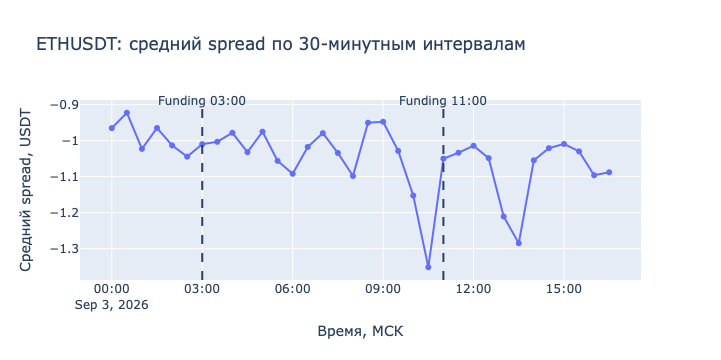

In [34]:
fig_eth_30min = go.Figure()

fig_eth_30min.add_trace(
    go.Scatter(
        x=eth_spread_30min.index,
        y=eth_spread_30min.values,
        mode="lines+markers",
        name="Средний spread за 30 минут"
    )
)

for funding_time, label in [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]:
    fig_eth_30min.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_eth_30min.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig_eth_30min.update_layout(
    title="ETHUSDT: средний spread по 30-минутным интервалам",
    xaxis_title="Время, МСК",
    yaxis_title="Средний spread, USDT",
    hovermode="x unified"
)

fig_eth_30min.show()

In [35]:
fig_eth_30min.write_html(
    "eth_spread_30min_funding.html",
    include_plotlyjs=True
)

### Наблюдение

На 30-минутном масштабе spread ETHUSDT большую часть периода находится около -1 USDT, то есть цена Perpetual преимущественно остается ниже цены Spot.

После Funding в 03:00 МСК заметного изменения spread не наблюдается: его значение остается примерно на том же уровне.

Перед Funding в 11:00 МСК наблюдается заметное увеличение spread по модулю — примерно до -1.35 USDT. После Funding spread сокращается примерно до -1.05 USDT, то есть цены Perpetual и Spot снова сближаются.

Таким образом, наиболее заметная динамика около Funding наблюдается в 11:00. расхождение увеличивается до момента Funding, а после него сокращается. При этом аналогичной реакции около Funding в 03:00 не наблюдается.

## ETHUSDT: средний spread по часовым интервалам

In [36]:
eth_spread_1h = (
    eth_spread_clean["spread_usd"]
    .resample("1h")
    .mean()
    .dropna()
)

eth_spread_1h

time
2026-09-03 00:00:00+03:00   -0.929444
2026-09-03 01:00:00+03:00   -0.993667
2026-09-03 02:00:00+03:00   -1.028667
2026-09-03 03:00:00+03:00   -1.006333
2026-09-03 04:00:00+03:00   -1.004917
2026-09-03 05:00:00+03:00   -1.015500
2026-09-03 06:00:00+03:00   -1.054667
2026-09-03 07:00:00+03:00   -1.006500
2026-09-03 08:00:00+03:00   -1.024000
2026-09-03 09:00:00+03:00   -0.987833
2026-09-03 10:00:00+03:00   -1.209286
2026-09-03 11:00:00+03:00   -1.042321
2026-09-03 12:00:00+03:00   -1.031167
2026-09-03 13:00:00+03:00   -1.219412
2026-09-03 14:00:00+03:00   -1.035000
2026-09-03 15:00:00+03:00   -1.019333
2026-09-03 16:00:00+03:00   -1.093488
Freq: h, Name: spread_usd, dtype: float64

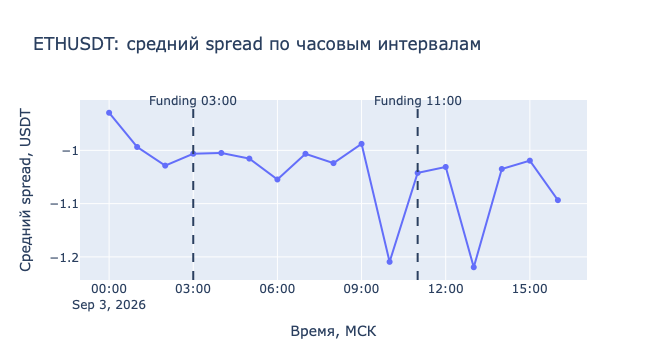

In [37]:
fig_eth_1h = go.Figure()

fig_eth_1h.add_trace(
    go.Scatter(
        x=eth_spread_1h.index,
        y=eth_spread_1h.values,
        mode="lines+markers",
        name="Средний spread за 1 час"
    )
)

for funding_time, label in [
    ("2026-09-03 03:00:00", "Funding 03:00"),
    ("2026-09-03 11:00:00", "Funding 11:00")
]:
    fig_eth_1h.add_shape(
        type="line",
        x0=funding_time,
        x1=funding_time,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(dash="dash")
    )

    fig_eth_1h.add_annotation(
        x=funding_time,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yshift=10
    )

fig_eth_1h.update_layout(
    title="ETHUSDT: средний spread по часовым интервалам",
    xaxis_title="Время, МСК",
    yaxis_title="Средний spread, USDT",
    hovermode="x unified"
)

fig_eth_1h.show()

### Наблюдение

На часовом масштабе spread ETHUSDT остается отрицательным на протяжении всего периода, то есть цена Perpetual находится в основном ниже цены Spot.

В районе Funding в 03:00 МСК выраженного изменения общего тренда не наблюдается: spread остается около -1 USDT.

Перед Funding в 11:00 МСК наблюдается заметное увеличение spread по модулю. После Funding расхождение сокращается и возвращается ближе к обычному уровню около -1 USDT.

Результаты часовой агрегации подтверждают наблюдение на 30-минутных данных: наиболее заметная динамика около Funding для ETHUSDT наблюдается в районе 11:00, тогда как около 03:00 выраженной реакции нет.

# Анализ завершающего Funding в 19:00 

В данном разделе отдельно рассматривается третее Funding-событие за исследуемый период с 16:00 до 22:00.

Сначала сравнивается динамика цен Spot и Perpetual в районе Funding, после чего отдельно анализируется spread между ними:

**Spread = Perpetual mid-price − Spot mid-price**

Отрицательный spread означает, что цена Perpetual находится ниже цены Spot, положительный — выше.

In [11]:
eth_spot_full = load_full_1min(
    "ethusdt_spot_2026-09-03_00-23-49_raw.csv"
)

eth_perp_full = load_full_1min(
    "ethusdt_usdm_futures_2026-09-03_00-24-09_raw.csv"
)

print("ETH Spot:", eth_spot_full.index.min(), "→", eth_spot_full.index.max())
print("ETH Perp:", eth_perp_full.index.min(), "→", eth_perp_full.index.max())

ETH Spot: 2026-09-03 00:23:00+03:00 → 2026-09-03 22:02:00+03:00
ETH Perp: 2026-09-03 00:24:00+03:00 → 2026-09-03 22:02:00+03:00


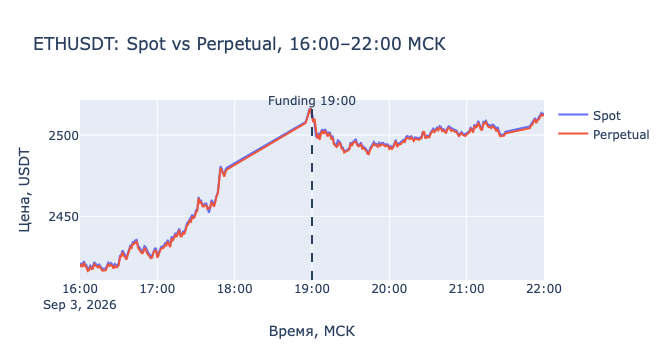

In [12]:
eth_spot_19 = eth_spot_full.loc[start:end]
eth_perp_19 = eth_perp_full.loc[start:end]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eth_spot_19.index,
    y=eth_spot_19.values,
    mode="lines",
    name="Spot"
))

fig.add_trace(go.Scatter(
    x=eth_perp_19.index,
    y=eth_perp_19.values,
    mode="lines",
    name="Perpetual"
))

fig.add_shape(
    type="line",
    x0="2026-09-03 19:00:00",
    x1="2026-09-03 19:00:00",
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(dash="dash")
)

fig.add_annotation(
    x="2026-09-03 19:00:00",
    y=1,
    xref="x",
    yref="paper",
    text="Funding 19:00",
    showarrow=False,
    yshift=10
)

fig.update_layout(
    title="ETHUSDT: Spot vs Perpetual, 16:00–22:00 МСК",
    xaxis_title="Время, МСК",
    yaxis_title="Цена, USDT",
    hovermode="x unified"
)

fig.show()

fig.write_html("eth_spot_vs_perp_16_22_funding_19.html")

/var/folders/x4/ng1slsx161z8z3235nhw7rtr0000gn/T/ipykernel_41244/1187851099.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  eth_spread_19 = pd.concat(


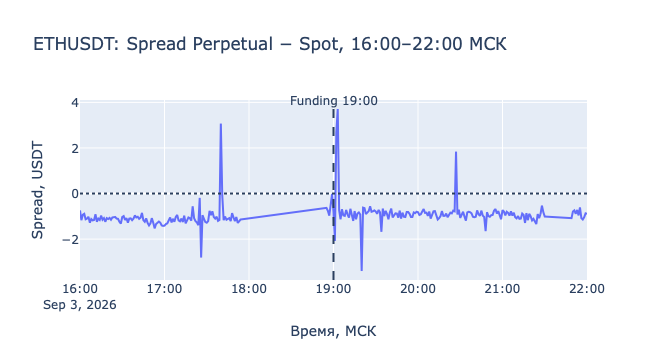

In [13]:
eth_spread_19 = pd.concat(
    [
        eth_spot_full.rename("spot_mid"),
        eth_perp_full.rename("perp_mid")
    ],
    axis=1
).dropna()

eth_spread_19["spread_usd"] = (
    eth_spread_19["perp_mid"] - eth_spread_19["spot_mid"]
)

eth_spread_19 = eth_spread_19.loc[start:end]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eth_spread_19.index,
    y=eth_spread_19["spread_usd"],
    mode="lines",
    name="Spread"
))

fig.add_shape(
    type="line",
    x0="2026-09-03 19:00:00",
    x1="2026-09-03 19:00:00",
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(dash="dash")
)

fig.add_annotation(
    x="2026-09-03 19:00:00",
    y=1,
    xref="x",
    yref="paper",
    text="Funding 19:00",
    showarrow=False,
    yshift=10
)

fig.add_hline(
    y=0,
    line_dash="dot"
)

fig.update_layout(
    title="ETHUSDT: Spread Perpetual − Spot, 16:00–22:00 МСК",
    xaxis_title="Время, МСК",
    yaxis_title="Spread, USDT",
    hovermode="x unified"
)

fig.show()

fig.write_html("eth_spread_16_22_funding_19.html")

### Наблюдение

На минутном масштабе можно увидеть краткосрочные колебания spread в районе Funding в 19:00 МСК, однако для оценки более устойчивой динамики необходимо дополнительно рассмотреть его среднее значение по 30-минутным интервалам.

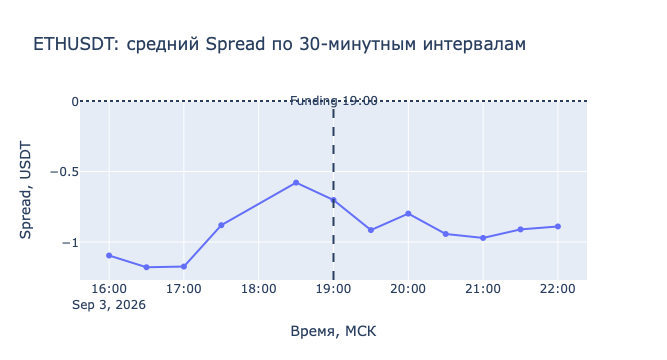

In [14]:
eth_spread_30 = (
    eth_spread_19["spread_usd"]
    .resample("30min")
    .mean()
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eth_spread_30.index,
    y=eth_spread_30.values,
    mode="lines+markers",
    name="30-min average spread",
    connectgaps=True
))

fig.add_shape(
    type="line",
    x0="2026-09-03 19:00:00",
    x1="2026-09-03 19:00:00",
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(dash="dash")
)

fig.add_annotation(
    x="2026-09-03 19:00:00",
    y=1,
    xref="x",
    yref="paper",
    text="Funding 19:00",
    showarrow=False,
    yshift=10
)

fig.add_hline(
    y=0,
    line_dash="dot"
)

fig.update_layout(
    title="ETHUSDT: средний Spread по 30-минутным интервалам",
    xaxis_title="Время, МСК",
    yaxis_title="Spread, USDT",
    hovermode="x unified"
)

fig.show()

fig.write_html("eth_spread_30min_funding_19.html")

### Наблюдение

30-минутная агрегация позволяет сгладить краткосрочные колебания и лучше увидеть общую динамику spread вокруг Funding в 19:00 МСК.

Отрицательные значения spread означают, что цена Perpetual находится ниже цены Spot. Движение spread в сторону нуля соответствует сближению цен, а увеличение отрицательного значения по модулю — расширению расхождения.

Для оценки реакции на Funding сравниваются значения spread в интервалах непосредственно перед 19:00 и после него.

### Вывод по ETHUSDT

На 30-минутном масштабе spread ETHUSDT в районе Funding в 19:00 МСК остается отрицательным, то есть цена Perpetual продолжает находиться ниже цены Spot.

Перед Funding наблюдается заметное сокращение spread по модулю, то есть цены Spot и Perpetual сближаются. После 19:00 spread снова увеличивается по модулю, а затем возвращается ближе к своему обычному уровню.

Таким образом, как и в случае с BTCUSDT, наиболее заметное сближение цен происходит непосредственно перед Funding, а не после него. После выплаты Funding устойчивого движения spread к нулю не наблюдается.

При этом часть временного интервала содержит пропуск данных из-за временного прекращения интернет-соединения, поэтому вывод относится только к доступным наблюдениям.

# Вывод

На исследуемых данных BTCUSDT и ETHUSDT не обнаружено мгновенной реакции spread на выплату Funding. Поведение spread различается между инструментами и отдельными Funding-событиями. Для BTC после Funding не наблюдалось немедленного сближения Spot и Perpetual, тогда как для ETH около Funding в 11:00 заметное расширение spread происходило до выплаты, а после неё расхождение сокращалось. Это показывает, что влияние механизма Funding нельзя оценивать только по изменению spread непосредственно после момента выплаты: необходимо анализировать динамику как до, так и после Funding и учитывать другие рыночные факторы, в том числе ликвидность.